In [1]:
import unyt
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets
import rebound

In [2]:
radius = 2 * unyt.ly
nstars = 25
bh_mass = 1e7
t_final = 10000 * unyt.year

In [3]:
xyz_init = unyt.ly * np.random.normal(loc = 0.0, scale = radius.in_units("ly").v / 2.5, size = (nstars, 3))
xyz_init.convert_to_units("AU")
masses = np.random.normal(loc = 2.5, scale = 1.0, size = nstars)
masses = np.maximum(masses, 0.1)

In [4]:
sim = rebound.Simulation()
sim.units = ('day', 'AU', 'Msun')

In [5]:
bh_mass

10000000.0

In [6]:
sim.add(m = bh_mass, x = 0, y = 0, z = 0)
for i in range(nstars):
    sim.add(x = xyz_init[i,0], y = xyz_init[i,1], z = xyz_init[i,2], m = masses[i])

In [7]:
def output_orbits(output_fn):
    sim.save_to_file(output_fn, interval = t_final.in_units("day").v / 500)
    sim.integrate(t_final.in_units("day"))

In [8]:
t_final.in_units("day").v / 500

np.float64(7305.0)

In [9]:
!rm output.bin

In [10]:
output_orbits("output.bin")

In [11]:
sim.t

3652500.0

In [12]:
import hashlib

In [13]:
sims = rebound.Simulationarchive("output.bin")
xyz_final = np.zeros((nstars + 1, 3), dtype="f8")

xyz_data = {}

@ipywidgets.interact(sim_index = (0, len(sims) - 1, 1))
def plot_it(sim_index = 0):
    sim = sims[sim_index]
    sim.serialize_particle_data(xyz = xyz_final)
    xyz_data[sim_index] = xyz_final.copy() - xyz_final[0,:]
    plt.scatter(xyz_final[:,0], xyz_final[:,1])
    plt.xlim(-radius.in_units("AU"), radius.in_units("AU"))
    plt.ylim(-radius.in_units("AU"), radius.in_units("AU"))
    plt.title(f"Time: {(sim.t * unyt.day).in_units("yr"):0.1f} - {hashlib.md5(xyz_final.tobytes()).hexdigest()}")

interactive(children=(IntSlider(value=0, description='sim_index', max=500), Output()), _dom_classes=('widget-i…

In [14]:
sims[-1].t

3652500.0

In [18]:
pos0 = xyz_data[0] * unyt.AU
posf = xyz_data[max(xyz_data.keys())] * unyt.AU

In [21]:
(posf - pos0).in_units("ly")

unyt_array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 4.54068864e-03,  8.75331389e-03, -4.77308003e-04],
       [-9.92672802e-01, -6.73521553e-02, -6.27244543e-01],
       [-4.15054557e-03, -3.42593969e-03, -4.50053708e-02],
       [-4.65323541e-01, -1.09264624e-01,  3.23800112e-01],
       [-2.59857722e-01,  1.43935608e-01,  8.95889498e-02],
       [-2.60344589e-02, -8.29214744e-02,  1.07228716e-01],
       [-3.31453672e-01, -3.60508112e-01,  3.76360471e-01],
       [ 2.80154058e-01,  2.85096267e-01, -2.09095493e-01],
       [ 1.38698038e-02,  6.63859297e-03, -3.08114666e-02],
       [ 1.98103806e-03,  2.84541121e-03,  4.42289387e-03],
       [-5.22201590e-03,  7.82887346e-03,  2.51875533e-03],
       [-5.27507444e-02, -1.18087017e-01, -7.17559827e-02],
       [-4.59162258e-01, -2.14492768e-01,  3.83028854e-01],
       [-2.24926784e-01, -1.27286507e-01,  3.82691683e-02],
       [-5.77614350e-02, -1.08504969e-02,  6.18369318e-02],
       [-2.45436856e+03,  5.8387997

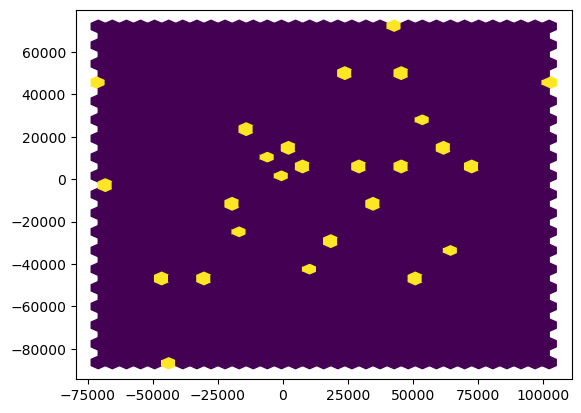

In [17]:
plt.hexbin(xyz_final[:,0], xyz_final[:,1], gridsize = 32)